Data Loading


In [ ]:
import pandas as pd
df_train1=pd.read_csv('train1_csv')
df_train1.head()

,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.323,00:00:01.673,1,1.1,LG_HG2_CyclesA,4.19155,-0.05108,23.76583,-0.00000,-0.00000.1,5.00000,Unnamed: 14
0,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.423,00:00:01.773,1,1,LG_HG2_CyclesA,4.19088,-0.08173,23.76583,-0.00000,-0.00001,5.0,NaN
1,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.522,00:00:01.872,1,1,LG_HG2_CyclesA,4.19054,-0.08939,23.76583,-0.00000,-0.00002,5.0,NaN
2,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.622,00:00:01.972,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00003,5.0,NaN
3,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.723,00:00:02.073,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00004,5.0,NaN
4,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.821,00:00:02.171,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00005,5.0,NaN


In [10]:
df_train1.columns = [
    "Time Stamp",
    "Step",
    "Status",
    "Prog Time",
    "Step Time",
    "Cycle",
    "Cycle Level",
    "Procedure",
    "Voltage",
    "Current",
    "Temperature",
    "Capacity",
    "WhAccu",
    "Cnt",
    "Empty",
]

In [11]:
df_train1 = df_train1.iloc[:, :-1]  # run only once
df_train1.head(3)

,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt
0,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.423,00:00:01.773,1,1,LG_HG2_CyclesA,4.19088,-0.08173,23.76583,-0.00000,-0.00001,5.0
1,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.522,00:00:01.872,1,1,LG_HG2_CyclesA,4.19054,-0.08939,23.76583,-0.00000,-0.00002,5.0
2,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.622,00:00:01.972,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00003,5.0


In [12]:
df_train1.describe()

,Step,Cycle,Cycle Level,Voltage,Current,Temperature,Capacity,WhAccu,Cnt
count,100763.000000,100763.000000,100763.000000,100763.000000,100763.000000,100763.000000,100763.000000,100763.000000,100763.0
mean,39.119111,3.590197,0.940444,3.702031,-0.926346,24.246026,-1.336233,-4.964102,5.0
std,0.473326,2.064147,0.236663,0.282690,2.406846,0.222317,0.789170,2.811615,0.0
min,39.000000,0.000000,0.000000,2.859260,-12.144700,23.660670,-2.590260,-9.263270,5.0
25%,39.000000,2.000000,1.000000,3.499510,-2.331880,24.081300,-1.999075,-7.365255,5.0
50%,39.000000,4.000000,1.000000,3.716890,-0.155800,24.186460,-1.303810,-4.958720,5.0
75%,39.000000,5.000000,1.000000,3.946430,0.000000,24.396780,-0.663455,-2.591270,5.0
max,41.000000,7.000000,1.000000,4.208720,5.999610,25.027730,-0.000000,-0.000010,5.0


In [13]:
df_train1.columns

Index(['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle',
       'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature',
       'Capacity', 'WhAccu', 'Cnt'],
      dtype='object')

In [14]:
df_train1=df_train1[(df_train1["Status"]=="DCH") | (df_train1["Status"]=="TABLE")]
df_train1.head(3)

,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt
0,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.423,00:00:01.773,1,1,LG_HG2_CyclesA,4.19088,-0.08173,23.76583,-0.00000,-0.00001,5.0
1,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.522,00:00:01.872,1,1,LG_HG2_CyclesA,4.19054,-0.08939,23.76583,-0.00000,-0.00002,5.0
2,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.622,00:00:01.972,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00003,5.0


In [15]:
max_discharge = abs(min(df_train1["Capacity"]))  # get maximum discharge
df_train1["SoC Capacity"] = max_discharge + df_train1["Capacity"]
df_train1["SoC Percentage"] = df_train1["SoC Capacity"] / max(
    df_train1["SoC Capacity"]
)

In [16]:
df_train1.shape

(94762, 16)

In [17]:
df_train1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94762 entries, 0 to 94761
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time Stamp      94762 non-null  object 
 1   Step            94762 non-null  int64  
 2   Status          94762 non-null  object 
 3   Prog Time       94762 non-null  object 
 4   Step Time       94762 non-null  object 
 5   Cycle           94762 non-null  int64  
 6   Cycle Level     94762 non-null  int64  
 7   Procedure       94762 non-null  object 
 8   Voltage         94762 non-null  float64
 9   Current         94762 non-null  float64
 10  Temperature     94762 non-null  float64
 11  Capacity        94762 non-null  float64
 12  WhAccu          94762 non-null  float64
 13  Cnt             94762 non-null  float64
 14  SoC Capacity    94762 non-null  float64
 15  SoC Percentage  94762 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 12.3+ MB


# **EDA**

In [18]:
df_train1["Prog Time"]

0        16:50:37.423
1        16:50:37.522
2        16:50:37.622
3        16:50:37.723
4        16:50:37.821
             ...     
94757    19:28:40.577
94758    19:28:40.678
94759    19:28:40.778
94760    19:28:40.878
94761    19:28:40.897
Name: Prog Time, Length: 94762, dtype: object

In [19]:

df_train1.head()

,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt,SoC Capacity,SoC Percentage
0,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.423,00:00:01.773,1,1,LG_HG2_CyclesA,4.19088,-0.08173,23.76583,-0.00000,-0.00001,5.0,2.59026,1.000000
1,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.522,00:00:01.872,1,1,LG_HG2_CyclesA,4.19054,-0.08939,23.76583,-0.00000,-0.00002,5.0,2.59026,1.000000
2,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.622,00:00:01.972,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00003,5.0,2.59025,0.999996
3,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.723,00:00:02.073,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00004,5.0,2.59025,0.999996
4,10/29/2018 3:53:42 AM,39,TABLE,16:50:37.821,00:00:02.171,1,1,LG_HG2_CyclesA,4.19037,-0.09195,23.76583,-0.00001,-0.00005,5.0,2.59025,0.999996


In [20]:
t1 = df_train1["Prog Time"][0]
time_parts = t1.split(":")
second_part = time_parts[2].split(".")
timedelta(
    hours=int(time_parts[0]),
    minutes=int(time_parts[1]),
    seconds=int(second_part[0]),
    microseconds=int(second_part[1]),
).total_seconds()

60637.000423

In [21]:
df_train1[df_train1.isna().any(axis=1)]

,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt,SoC Capacity,SoC Percentage


In [22]:
df_train1[df_train1.isna().any(axis=1)]

,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt,SoC Capacity,SoC Percentage


In [23]:
df_train1.columns

Index(['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle',
       'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature',
       'Capacity', 'WhAccu', 'Cnt', 'SoC Capacity', 'SoC Percentage'],
      dtype='object')

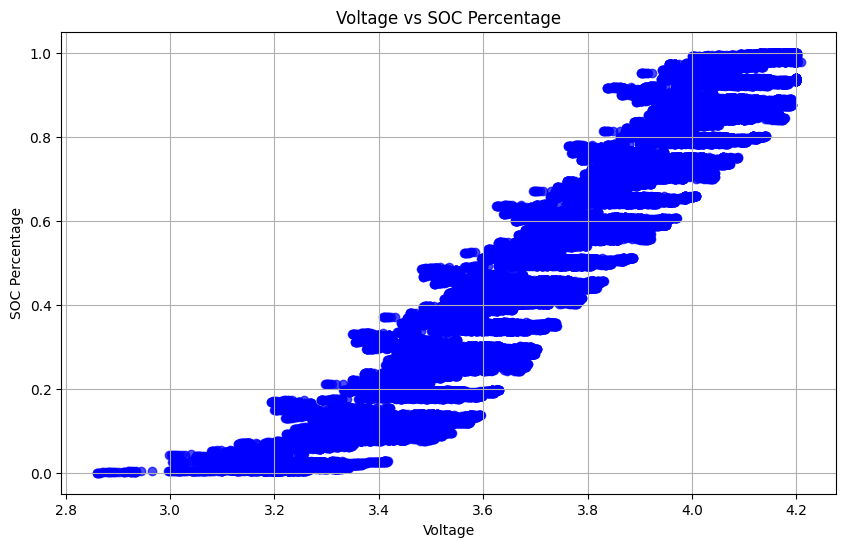

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(df_train1['Voltage'], df_train1['SoC Percentage'], color='blue', alpha=0.7)
plt.title('Voltage vs SOC Percentage')
plt.xlabel('Voltage')
plt.ylabel('SOC Percentage')
plt.grid(True)
plt.show()

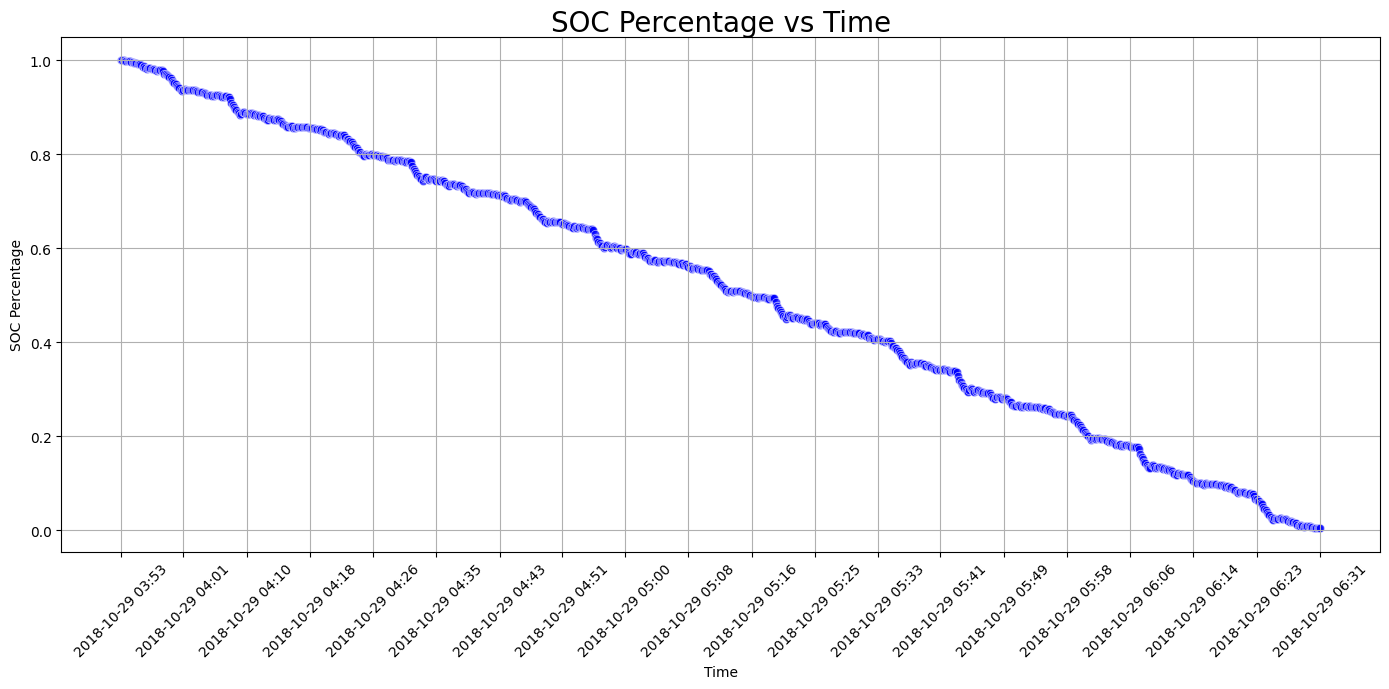

In [25]:
df_sampled = df_train1.iloc[::100, :]

# Extracting 'Time Stamp' and 'SoC Percentage' as numpy arrays
x_val = df_sampled['Time Stamp'].to_numpy()
y_val = df_sampled['SoC Percentage'].to_numpy()

# Define x-tick values (e.g., every 20th point in the downsampled data)
num_ticks = 20
x_ticks_val = np.linspace(0, len(x_val) - 1, num=num_ticks, dtype=int)

# Plotting SOC Percentage vs Time using Seaborn
plt.figure(figsize=(14, 7))
sns.scatterplot(x=x_val, y=y_val, color='blue', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('SOC Percentage')
plt.title('SOC Percentage vs Time', fontdict={'fontsize': 20, 'fontweight': 3, 'verticalalignment': 'center', 'horizontalalignment': 'center'})

# Customizing x-ticks
plt.xticks(ticks=x_val[x_ticks_val], labels=[pd.to_datetime(label).strftime('%Y-%m-%d %H:%M') for label in df_sampled['Time Stamp'].iloc[x_ticks_val]], rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


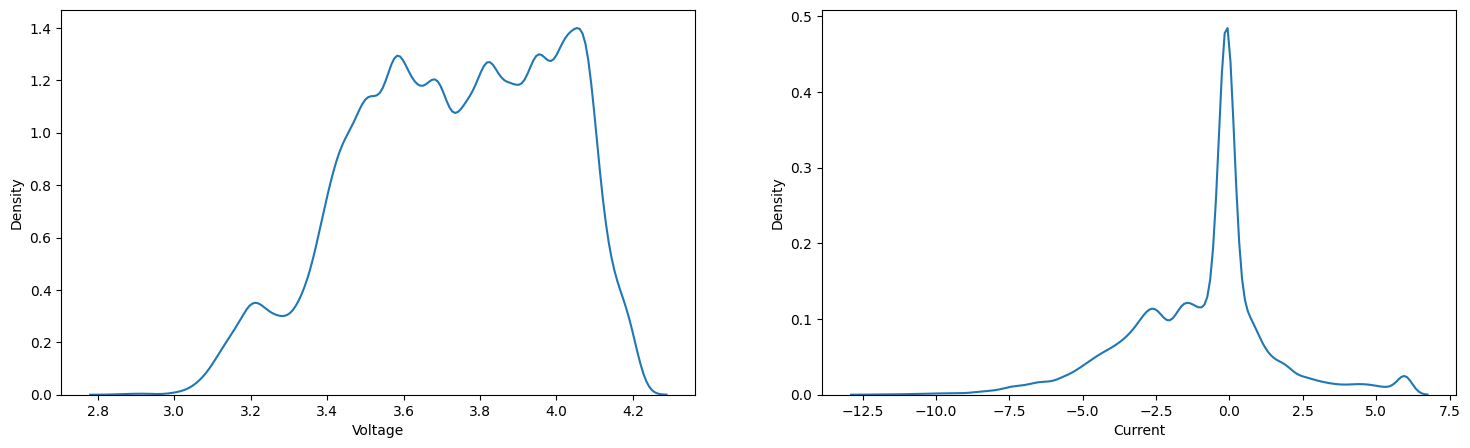

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.kdeplot(data=df_train1, x="Voltage", ax=axes[0])
sns.kdeplot(data=df_train1, x="Current", ax=axes[1])
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sc = StandardScaler()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

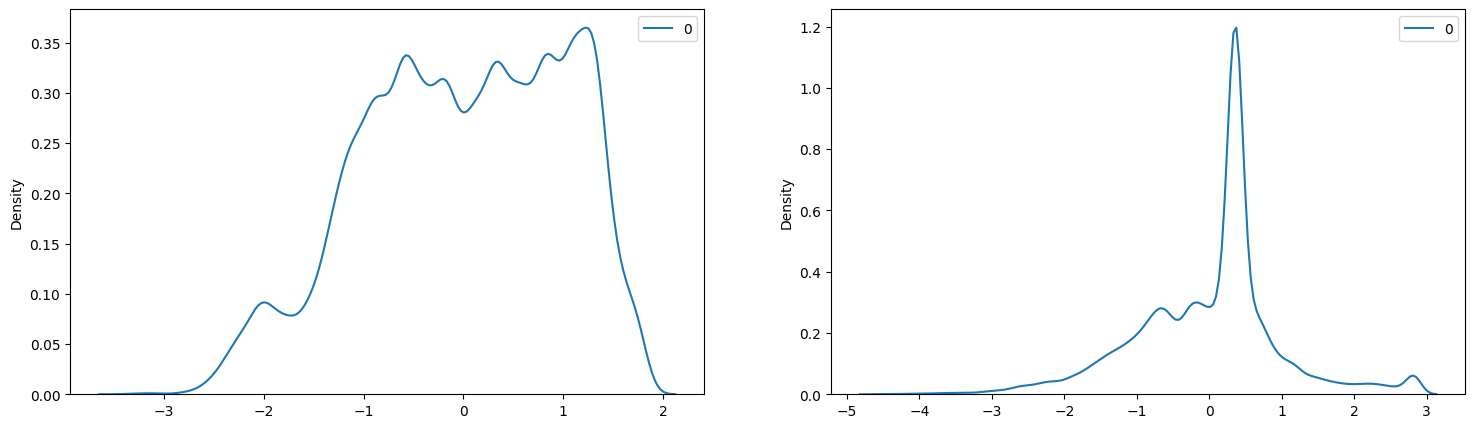

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

x = sc.fit_transform(df_train1["Voltage"].to_numpy().reshape(-1, 1))
x1 = sc.fit_transform(df_train1["Current"].to_numpy().reshape(-1, 1))
sns.kdeplot(data=x, ax=axes[0])
sns.kdeplot(data=x1, ax=axes[1])
plt.show()

In [29]:
df_train1[["Voltage", "Current", "Temperature"]].head()

,Voltage,Current,Temperature
0,4.19088,-0.08173,23.76583
1,4.19054,-0.08939,23.76583
2,4.19037,-0.09195,23.76583
3,4.19037,-0.09195,23.76583
4,4.19037,-0.09195,23.76583


In [30]:
x = df_train1[["Voltage", "Current", "Temperature"]].to_numpy()
y = df_train1[["SoC Percentage"]].to_numpy()

In [31]:
cycles = []
cycles.append((x, y))

In [32]:
cycles[0] # x, y pair
print(cycles[0][0]) # gives x
print(cycles[0][1]) # gives Y
print(cycles[0][0][0]) # gives voltage, current, temperature values


[[ 4.19088 -0.08173 23.76583]
 [ 4.19054 -0.08939 23.76583]
 [ 4.19037 -0.09195 23.76583]
 ...
 [ 2.86179 -9.93796 24.39678]
 [ 2.85977 -9.94562 24.39678]
 [ 2.85926 -9.95073 24.39678]]
[[1.00000000e+00]
 [1.00000000e+00]
 [9.99996139e-01]
 ...
 [2.12333897e-04]
 [1.08097257e-04]
 [0.00000000e+00]]
[ 4.19088 -0.08173 23.76583]


Data Cleaning

In [33]:
Main_Path ="/kaggle/input/lg-18650hg2-liion-battery-data"


In [35]:
def get_discharge_whole_cycle(
    train_files, test_files, output_capacity=False, scale_test=False, output_time=False
):
    """
    This function returns the train and test data for all the cycle
    according to the file paths provided
    and scales according to the user input.
    """
    train = _get_data(train_files, output_capacity, output_time)
    test = _get_data(test_files, output_capacity, output_time)
    train, test = _scale_x(train, test, scale_test=scale_test)
    return (train, test)


# --------------------------------------------------------------------------#


def _get_data(names, output_capacity, output_time=False):
    """
    Returns a tuple of (x, y) values for every file path
    """
    cycles = []
    for name in names:
        #         print(f"Extracting for {name}...")
        cycle = pd.read_csv(Main_Path +"/Dataset_Li-ion/"+ name + ".csv", skiprows=30)
        cycle.columns = [
            "Time Stamp",
            "Step",
            "Status",
            "Prog Time",
            "Step Time",
            "Cycle",
            "Cycle Level",
            "Procedure",
            "Voltage",
            "Current",
            "Temperature",
            "Capacity",
            "WhAccu",
            "Cnt",
            "Empty",
        ]
        cycle = cycle[(cycle["Status"] == "TABLE") | (cycle["Status"] == "DCH")]

        max_discharge = abs(min(cycle["Capacity"]))
        cycle["SoC Capacity"] = max_discharge + cycle["Capacity"]
        cycle["SoC Percentage"] = cycle["SoC Capacity"] / max(cycle["SoC Capacity"])
        x = cycle[["Voltage", "Current", "Temperature"]].to_numpy()

        if output_time:
            cycle["Prog Time"] = cycle["Prog Time"].apply(_time_string_to_seconds)
            cycle["Time in Seconds"] = cycle["Prog Time"] - cycle["Prog Time"][0]

        if output_capacity:
            if output_time:
                y = cycle[["SoC Capacity", "Time in Seconds"]].to_numpy()
            else:
                y = cycle[["SoC Capacity"]].to_numpy()
        else:
            if output_time:
                y = cycle[["SoC Percentage", "Time in Seconds"]].to_numpy()
            else:
                y = cycle[["SoC Percentage"]].to_numpy()

        if np.isnan(np.min(x)) or np.isnan(np.min(y)):
            print(f"There is a NaN in cycle {name}, removing row")
            x = x[~np.isnan(x).any(axis=1)]
            y = y[~np.isnan(y).any(axis=1)].reshape(-1, y.shape[1])

        cycles.append((x, y))

    return cycles


# ---------------------------------------------------------------#


from sklearn.preprocessing import MinMaxScaler
import numpy as np

def _scale_x(train, test, scale_test=False):
    # Flatten train data to fit MinMaxScaler
    train_features = np.concatenate([cycle[0] for cycle in train], axis=0)
    # Initialize the scaler
    scaler = MinMaxScaler()
    # Fit and transform the train data
    scaler.fit(train_features)
    # Create new lists for transformed train and test data
    scaled_train = []
    scaled_test = []
    for i in range(len(train)):
        scaled_cycle = (scaler.transform(train[i][0]), train[i][1])
        scaled_train.append(scaled_cycle)
    if scale_test:
        for i in range(len(test)):
            scaled_cycle = (scaler.transform(test[i][0]), test[i][1])
            scaled_test.append(scaled_cycle)
    else:
        scaled_test = test  # If not scaling test, keep original test data
        
    return scaled_train, scaled_test

# ---------------------------------------------------------------#
print("Done")

Done


# Train_test_split

In [36]:
def _time_string_to_seconds(input_string):
    time_parts = input_string.split(":")
    second_parts = time_parts[2].split(".")
    return timedelta(
        hours=int(time_parts[0]),
        minutes=int(time_parts[1]),
        seconds=int(second_parts[0]),
        microseconds=int(second_parts[1]),
    ).total_seconds()


# ---------------------------------------------------------------#


def get_discharge_multiple_step(cycles, steps):
    train_x, train_y = _split_to_multiple_step(cycles[0], steps)
    test_x, test_y = _split_to_multiple_step(cycles[1], steps)
    return (train_x, train_y, test_x, test_y)


# ---------------------------------------------------------------#


def _split_to_multiple_step(cycles, steps):
    x_length = len(cycles[0][0][0])
    y_length = len(cycles[0][1][0])
    x = np.empty((0, steps, x_length), float)
    y = np.empty((0, steps, y_length), float)
    for cycle in cycles:
        for i in range(0, len(cycle[0]) - steps, steps):
            next_x = np.array(cycle[0][i : i + steps]).reshape(1, steps, x_length)
            next_y = np.array(cycle[1][i : i + steps]).reshape(1, steps, y_length)
            x = np.concatenate((x, next_x))
            y = np.concatenate((y, next_y))
    return x, y


# ---------------------------------------------------------------#


def keep_only_y_end(y, step, is_stateful=False):
    if is_stateful:
        return y[:, :, ::step]
    else:
        return y[:, ::step]


print("Done")

Done


**Set up training data,test data and other parameters**

In [37]:
train_files = [
    #'0degC/589_LA92',
    #  '0degC/590_Mixed6',
    #  '0degC/590_Mixed8',
    #  '0degC/589_Mixed1',
    #  '0degC/589_US06',
    #  '10degC/567_Mixed1',
    #  '10degC/571_Mixed8',
    #  '10degC/571_Mixed4',
    #  '10degC/571_Mixed6',
    #  '10degC/567_Mixed2',
    #     '25degC/551_Mixed1',
    #     '25degC/551_Mixed2',
    '25degC/551_UDDS',
    #     '25degC/552_Mixed3',
    #     '25degC/552_Mixed8'
    "0degC/589_LA92",
    "0degC/589_UDDS",
    "0degC/589_Mixed1",
    "0degC/589_Mixed2",
    "0degC/590_Mixed4",
    "0degC/590_Mixed5",
    "0degC/590_Mixed6",
    "0degC/590_Mixed8",
    "10degC/567_US06",
    "10degC/571_Mixed7",
    "10degC/567_Mixed1",
    "10degC/567_Mixed2",
    "10degC/571_Mixed4",
    "10degC/571_Mixed5",
    "10degC/571_Mixed6",
    "10degC/571_Mixed8",
    "25degC/551_Mixed1",
    "25degC/551_Mixed2",
    #'25degC/552_Mixed3',
    "25degC/551_LA92",
    "25degC/551_UDDS",
    "25degC/552_Mixed4",
    "25degC/552_Mixed5",
    "25degC/552_Mixed6",
    "25degC/552_Mixed8",
]
test_files = [
    #     "0degC/589_UDDS",
    #     "0degC/589_US06",
    #     "0degC/590_Mixed7",
    #     "10degC/582_LA92",
    #     "10degC/567_US06",
    #     "10degC/571_Mixed7",
    #     "25degC/551_LA92",
    #     "25degC/551_US06",
    #     "25degC/552_Mixed7",
    
    "0degC/589_US06",
    "0degC/590_Mixed7",
    "10degC/582_LA92",
    "10degC/576_UDDS",
    

    "25degC/551_US06",
    "25degC/552_Mixed7",
]
steps = 300
# stateful_config = True

In [38]:
%%time
cycles = get_discharge_whole_cycle(train_files, test_files, output_capacity=False, scale_test=True)
#/kaggle/input/lg-18650hg2-liion-battery-data/Dataset_Li-ion/0degC/589_Mixed1.csv

There is a NaN in cycle 10degC/582_LA92, removing row
CPU times: user 7.38 s, sys: 1.11 s, total: 8.49 s
Wall time: 10.6 s


**Issue with file directory**

In [ ]:
#/kaggle/input/lg-18650hg2-liion-battery-data/Dataset_Li-ion/0degC/589_Mixed1.csv

In [40]:
print(
    f"First element of cycles has {len(cycles[0])} files and they belong to training data.\nSecond element of cycles has {len(cycles[1])} files and they belong to test data."
)

print("Train/Test %d" % len(cycles))
print("x/y :%d" % len(cycles[0][0]))
print("time_steps: %d" % len(cycles[0][0][0]))
print("x features: %d" % len(cycles[0][0][0][0]))

First element of cycles has 25 files and they belong to training data.
Second element of cycles has 6 files and they belong to test data.
Train/Test 2
x/y :2
time_steps: 153644
x features: 3


In [48]:
steps

300

In [41]:
df = get_discharge_multiple_step(cycles, steps)

In [49]:
type(df)

tuple

In [44]:
df.to_csv("/kaggle/working/train.csv", index=False)
from IPython.display import FileLink

FileLink('/kaggle/working/train.csv')

AttributeError: 'tuple' object has no attribute 'to_csv'

**Split data into train and test**

In [50]:
# new
train_x, train_y, test_x, test_y = get_discharge_multiple_step(cycles, steps)

In [53]:
train_x.shape, train_y.shape, test_x.shape, test_y.shape

((6426, 300, 3), (6426, 300, 1), (1372, 300, 3), (1372, 300, 1))

Use helper function keep_only_y_end

In [54]:
train_y = keep_only_y_end(train_y, steps)
test_y = keep_only_y_end(test_y, steps)

# Training the model

In [55]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation,InputLayer
from tensorflow.keras.optimizers import SGD, Adam
#from keras.utils import np_utils
from keras.layers import LSTM,  BatchNormalization,RepeatVector, TimeDistributed, Masking,Bidirectional
from keras.callbacks import EarlyStopping, ModelCheckpoint, LambdaCallback

2025-07-09 06:48:36.749020: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-09 06:48:36.749173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-09 06:48:37.024016: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [56]:

ist = pytz.timezone("Asia/Kolkata")
current_time_ist = datetime.now(ist)
print("Current Time in IST: ", current_time_ist.strftime("%Y-%m-%d %H:%M:%S"))

Current Time in IST:  2025-07-09 12:18:51


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, InputLayer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datetime import datetime
import tensorflow as tf
import os

EXPERIMENT = "gru_mlp_soc_percentage_lg_positive_temp_300_steps_mixed_cycle_test"
experiment_name = datetime.now().strftime("%Y:%m:%d-%H:%M:%S") + "_" + EXPERIMENT
print(f"We are performing: {experiment_name}")

# Optimizer
opt = tf.keras.optimizers.Adam(learning_rate=0.00001)

# Model architecture
model = Sequential()
model.add(InputLayer(input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(GRU(64, activation="selu", return_sequences=False))  # GRU layer
model.add(Dense(256, activation="selu"))
model.add(Dense(128, activation="selu"))
model.add(Dense(64, activation="selu"))
model.add(Dense(1, activation="linear"))  # Regression output

model.summary()

# Compile model
model.compile(
    optimizer=opt,
    loss="huber",  # smooth L1 loss
    metrics=["mse", "mae", "mape", tf.keras.metrics.RootMeanSquaredError(name="rmse")],
)

# Callbacks
os.makedirs("/kaggle/working/results/trained_model/", exist_ok=True)

es = EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)
mc = ModelCheckpoint(
    f"/kaggle/working/results/trained_model/{experiment_name}_best.keras",
    save_best_only=True,
    monitor="val_loss",
)


We are performing: 2025:07:09-06:49:29_gru_mlp_soc_percentage_lg_positive_temp_300_steps_mixed_cycle_test


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,105 (277.75 KB)

 Trainable params: 71,105 (277.75 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
%%time
history = model.fit(train_x, train_y, 
                                epochs=120, 
                                batch_size=32, 
                                verbose=1,
                                validation_split=0.2,
                                callbacks = [mc, es]
                               )

Epoch 1/120
  7/161 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.1293 - mae: 0.4142 - mape: 175.3472 - mse: 0.2586 - rmse: 0.5085

I0000 00:00:1752043796.716005     133 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 0.0746 - mae: 0.3145 - mape: 177.9103 - mse: 0.1493 - rmse: 0.3826 - val_loss: 0.0322 - val_mae: 0.2181 - val_mape: 186.8357 - val_mse: 0.0644 - val_rmse: 0.2538
Epoch 2/120
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0228 - mae: 0.1816 - mape: 132.8786 - mse: 0.0457 - rmse: 0.2131 - val_loss: 0.0098 - val_mae: 0.1207 - val_mape: 88.0162 - val_mse: 0.0195 - val_rmse: 0.1397
Epoch 3/120
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0077 - mae: 0.1035 - mape: 60.6019 - mse: 0.0154 - rmse: 0.1238 - val_loss: 0.0021 - val_mae: 0.0546 - val_mape: 30.3362 - val_mse: 0.0042 - val_rmse: 0.0646
Epoch 4/120
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0027 - mae: 0.0566 - mape: 37.1646 - mse: 0.0053 - rmse: 0.0731 - val_loss: 8.5401e-04 - val_mae: 0.0323 - val_mape: 27.1186 - val_mse: 0.0017 - val_rmse: 0.0413
Epoch 5/120
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0019 - mae: 0.0456 - mape: 34.0615 - mse: 0.0038 - r

In [59]:
experiment_name  # Replace with your actual experiment name

# Save the model
model_path = "/kaggle/working/results/trained_model/{}_model2.h5".format(experiment_name)
model.save(model_path)


**Test the model**

In [60]:
model.evaluate(test_x, test_y)


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0015 - mae: 0.0409 - mape: 13.6964 - mse: 0.0030 - rmse: 0.0536


[0.0009607037645764649,
 0.0019214075291529298,
 0.0336502343416214,
 15.624914169311523,
 0.043833862990140915]

In [66]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history["loss"], mode="lines", name="train"))
fig.add_trace(
    go.Scatter(y=history.history["val_loss"], mode="lines", name="validation")
)
fig.update_layout(title="Loss trend", xaxis_title="epoch", yaxis_title="loss")
fig.show()

**RMSE**

In [67]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history["rmse"], mode="lines", name="train"))
fig.add_trace(
    go.Scatter(y=history.history["val_rmse"], mode="lines", name="validation")
)
fig.update_layout(title="RMSE trend", xaxis_title="epoch", yaxis_title="rmse")
fig.show()

**MAE Trend**

In [68]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history["mae"], mode="lines", name="train"))
fig.add_trace(
    go.Scatter(y=history.history["val_mae"], mode="lines", name="validation")
)
fig.update_layout(title="MAE trend", xaxis_title="epoch", yaxis_title="mae")
fig.show()

In [69]:
train_predictions = model.predict(train_x)

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [70]:
cycle_num = 0
steps_num = 8000
step_index = np.arange(cycle_num * steps_num, (cycle_num + 1) * steps_num)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=step_index,
        y=train_predictions.flatten()[
            cycle_num * steps_num : (cycle_num + 1) * steps_num
        ],
        mode="lines",
        name="SoC predicted",
    )
)
fig.add_trace(
    go.Scatter(
        x=step_index,
        y=train_y.flatten()[cycle_num * steps_num : (cycle_num + 1) * steps_num],
        mode="lines",
        name="SoC actual",
    )
)
fig.update_layout(
    title="Results on training", xaxis_title="Step", yaxis_title="SoC percentage"
)
fig.show()

In [71]:
test_predictions = model.predict(test_x)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [72]:
cycle_num = 0
steps_num = 8000
step_index = np.arange(cycle_num * steps_num, (cycle_num + 1) * steps_num)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=step_index,
        y=test_predictions.flatten()[
            cycle_num * steps_num : (cycle_num + 1) * steps_num
        ],
        mode="lines",
        name="SoC predicted",
    )
)
fig.add_trace(
    go.Scatter(
        x=step_index,
        y=test_y.flatten()[cycle_num * steps_num : (cycle_num + 1) * steps_num],
        mode="lines",
        name="SoC actual",
    )
)
fig.update_layout(
    title="Results on testing", xaxis_title="Step", yaxis_title="SoC percentage"
)
fig.show()

# **Predictions on testing**

In [73]:
test_predictions = model.predict(test_x)
test_evaluate=model.evaluate(test_x,test_y)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - mae: 0.0409 - mape: 13.6964 - mse: 0.0030 - rmse: 0.0536


In [74]:
cycle_num = 0
steps_num = 8000
step_index = np.arange(cycle_num * steps_num, (cycle_num + 1) * steps_num)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=step_index,
        y=test_predictions.flatten()[
            cycle_num * steps_num : (cycle_num + 1) * steps_num
        ],
        mode="lines",
        name="SoC predicted",
    )
)
fig.add_trace(
    go.Scatter(
        x=step_index,
        y=test_y.flatten()[cycle_num * steps_num : (cycle_num + 1) * steps_num],
        mode="lines",
        name="SoC actual",
    )
)
fig.update_layout(
    title="Results on testing", xaxis_title="Step", yaxis_title="SoC percentage"
)
fig.show()